<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2/05_heterogeneous_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heterogeneous Price Elasticities with Embedding-Based Effect Modifiers

This notebook is the last of five labs that accompany [Bach et al. (2025)](https://arxiv.org/abs/2501.00382). It requires the embeddings saved in **Lab 2**.

In Lab 4, we estimated a single average effect: a 1% price increase reduces units sold by roughly 1.5%. Sellers, however, do not set prices for the average product, so the more relevant question is which products are sensitive to prices and which are not. In this lab, we estimate the price elasticity as a function of product characteristics.

## From the ACE to the CACE

Recall that $A_{it} = a_t(S_{it}, \epsilon_{it})$ denotes the price sensitivity of product $i$ in period $t$. In Lab 4, we estimated its unconditional mean. Here, we estimate the conditional average causal effect (CACE),

$$\alpha_t(S_{it}) := E[A_{it}\mid S_{it}],$$

that is, the part of the variation in price sensitivity that can be predicted from what we observe.

Proposition 1 of the paper shows that, under the structural assumptions of Lab 4, the CACE is identified by the conditional average predictive effect,

$$\alpha_t(S_{it}) = \delta_t(S_{it}) :=
\frac{E\!\left[Q^{\perp}_{it}P^{\perp}_{it}\mid S_{it}\right]}
     {E\!\left[(P^{\perp}_{it})^{2}\mid S_{it}\right]}.$$

In words, we partial out the state as in Lab 4 and then let the slope of the regression of the outcome residual on the price residual vary with the characteristics of interest.

## The Specification

Following Model II of the paper, the elasticity is linear in a small set of basis functions:

$$\alpha(S_{it}) = a_0 + \sum_{k=1}^{5}\alpha_k X^{sim}_{i,k}
                 + b_1 P_{i,t-1} + b_2 Q_{i,t-1}.$$

The two kinds of effect modifiers answer different questions. The cluster similarities $X^{sim}_{i,k}$ describe what kind of product it is; Lab 3 showed that five similarities carry about as much information as the full 256-dimensional embedding, which keeps the model interpretable. Lagged price and quantity describe how expensive and how popular the product currently is.

The intercept $a_0$ is the average effect and should be close to the estimate from Lab 4.

We estimate this model in three ways, corresponding to Models II-1, II-2 and II-3 of the paper. As before, we use the estimation products only and cluster the standard errors by product.

First, we install and load the required packages.

In [1]:
%pip install -q doubleml lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.8/607.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.7/531.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.3 MB/s eta 0:00:00


In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor
from scipy.linalg import sqrtm
from scipy.stats import chi2, norm

palette = sns.color_palette("colorblind")
warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.width", 140)

CONFIDENCE = 0.90
RANK_TO_DEMAND = 2.0
SEED = 42

## Data

We load the data saved in Lab 2 from Google Drive. If the file is not found there, the cell also looks for a copy uploaded to the current session.

In [3]:
ARTIFACT = "subsample_v2.parquet"
drive_path = f"/content/drive/MyDrive/demand_labs_v2/{ARTIFACT}"

# Colab gives every notebook its own machine, so /content does not carry across
# labs. Google Drive does.
if os.path.isdir("/content") and not os.path.exists(drive_path):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"could not mount Drive ({type(exc).__name__})")

path = next((p for p in [drive_path, f"/content/{ARTIFACT}", ARTIFACT]
             if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        "subsample_v2.parquet not found. Run Lab 2 "
        "(02_finetune_embeddings.ipynb) first and let it save to Google Drive, "
        "or upload the file into this session.")

df = pd.read_parquet(path)
print(f"loaded {path}")
print(f"{df['ASIN'].nunique():,} products, {len(df):,} rows, "
      f"{df['period'].nunique()} periods")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size")))

Mounted at /content/drive
loaded /content/drive/MyDrive/demand_labs_v2/subsample_v2.parquet
1,540 products, 21,560 rows, 14 periods
            products   rows
split                      
estimation       770  10780
finetune         770  10780


As in Lab 4, we define the groups of variables and restrict the sample to the estimation products.

In [4]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
pca_cols = [c for c in df.columns if c.startswith("pca_")]
sim_cols = [c for c in df.columns if c.startswith("similarity_cluster_")]
sub_cols = [c for c in df.columns if c.startswith("sub_")]

lag_controls = ["Q_t-1", "P_bb_t-1"]
tab_controls = ["RATING_t-1", "REVIEW_COUNT_t-1", "n_offers",
                "n_offers_fba", "n_offers_fbm", "lightning_deal", "is_fba"]

periods = sorted(df["period"].unique())[1:]   # first period is the baseline
period_cols = [f"period_{p}" for p in periods]
for p in periods:
    df[f"period_{p}"] = (df["period"] == p).astype(int)

OUTCOME, TREATMENT = "Q_t", "P_bb_t"
X_o = tab_controls + sub_cols + period_cols

data = (df[df["split"] == "estimation"]
        .dropna(subset=lag_controls + tab_controls + [OUTCOME, TREATMENT])
        .reset_index(drop=True))
clusters = data["ASIN"]

print(f"estimation sample: {len(data):,} observations, "
      f"{data['ASIN'].nunique()} products")

estimation sample: 10,010 observations, 770 products


## Basis Functions

The basis consists of an intercept and seven effect modifiers. We center and standardize the lagged variables, so that their coefficients measure the change in the elasticity per standard deviation of popularity or price. We only center the similarities, since they already share a common cosine scale.

In [5]:
def make_basis(frame, scaled, unscaled):
    """Intercept + standardised `scaled` columns + centred `unscaled` columns."""
    out = pd.DataFrame({"intercept": np.ones(len(frame))}, index=frame.index)
    for c in scaled:
        out[c] = (frame[c] - frame[c].mean()) / frame[c].std()
    for c in unscaled:
        out[c] = frame[c] - frame[c].mean()
    return out


basis = make_basis(data, scaled=lag_controls, unscaled=sim_cols)
BASIS_COLS = list(basis.columns)
SIM_IDX = [BASIS_COLS.index(c) for c in sim_cols]
MOD_IDX = [i for i, c in enumerate(BASIS_COLS) if c != "intercept"]

print("basis:", BASIS_COLS)
basis.head(3).round(3)

basis: ['intercept', 'Q_t-1', 'P_bb_t-1', 'similarity_cluster_0', 'similarity_cluster_1', 'similarity_cluster_2', 'similarity_cluster_3', 'similarity_cluster_4']


,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,-0.671,0.242,-0.179,0.191,0.296,-0.113,-0.202
1,1.0,-0.618,0.272,-0.179,0.191,0.296,-0.113,-0.202
2,1.0,-0.725,0.277,-0.179,0.191,0.296,-0.113,-0.202


## Estimation

Models II-1 and II-2 are linear. We residualize $Q$ and $P$ on the controls by OLS and then regress the outcome residual on the basis functions interacted with the price residual. Model II-2 additionally includes interactions between the lagged state and the similarities in the control function.

Model II-3 is partially linear. The second stage is the same, but the residuals come from cross-fitted boosted trees estimated with `DoubleML`, so the control function is nonparametric. We obtain the second stage with the `cate` method of the fitted `DoubleMLPLR` object.

In [6]:
def lin_model_cate(frame, basis, controls, treatment=TREATMENT, outcome=OUTCOME):
    """Residual-on-residual regression with a varying slope (Models II-1, II-2)."""
    X = sm.add_constant(frame[controls], has_constant="add")
    y_tilde = frame[outcome] - sm.OLS(frame[outcome], X).fit().predict(X)
    d_tilde = frame[treatment] - sm.OLS(frame[treatment], X).fit().predict(X)
    interacted = basis.mul(d_tilde.values, axis=0)
    return sm.OLS(y_tilde, interacted).fit(
        cov_type="cluster", cov_kwds={"groups": clusters})


# Model II-2 needs the interaction terms in the *control* function
inter_cols = []
for lag in lag_controls:
    for s in sim_cols:
        name = f"int_{lag}_{s}"
        data[name] = data[lag] * data[s]
        inter_cols.append(name)

controls_base = lag_controls + emb_cols + X_o

models = {}
models["II-1 Linear"] = lin_model_cate(data, basis, controls_base)
models["II-2 Linear (interactions)"] = lin_model_cate(
    data, basis, controls_base + inter_cols)
print("linear specifications fitted")

/tmp/ipykernel_559/3995971268.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  y_tilde = frame[outcome] - sm.OLS(frame[outcome], X).fit().predict(X)
/tmp/ipykernel_559/3995971268.py:5: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  d_tilde = frame[treatment] - sm.OLS(frame[treatment], X).fit().predict(X)
/tmp/ipykernel_559/3995971268.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  y_tilde = frame[outcome] - sm.OLS(frame[outcome], X).fit().predict(X)


linear specifications fitted


/tmp/ipykernel_559/3995971268.py:5: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  d_tilde = frame[treatment] - sm.OLS(frame[treatment], X).fit().predict(X)


In [7]:
dml_controls = lag_controls + sim_cols + X_o
dml_data = DoubleMLData(data[[OUTCOME, TREATMENT, "ASIN"] + dml_controls],
                        y_col=OUTCOME, d_cols=TREATMENT,
                        x_cols=dml_controls, cluster_cols="ASIN")

learner = dict(n_estimators=500, learning_rate=0.02, random_state=SEED, verbose=-1)
np.random.seed(3141)
plr = DoubleMLPLR(dml_data,
                  ml_l=LGBMRegressor(**learner),
                  ml_m=LGBMRegressor(**learner),
                  score="partialling out", n_folds=3)
plr.fit(store_predictions=True)
print(f"average effect from Lab 4's estimator: {plr.coef[0]:+.3f}")

blp = plr.cate(basis, cov_type="cluster", cov_kwds={"groups": clusters})
# recent doubleml releases keep one OLS fit per repetition; n_rep is 1 here
blp_fit = blp.blp_model
models["II-3 PLR (boosted trees)"] = blp_fit[0] if isinstance(blp_fit, list) else blp_fit

average effect from Lab 4's estimator: -0.733


## The Elasticity Function

The partially linear estimator in Model II-3 reproduces the average effect of $-0.733$ from Lab 4. The table below corresponds to Table 8 of the paper. The `intercept` row gives the average effect, and every other row gives the change in the elasticity as the respective modifier increases.

In [8]:
def summarise(res, level=CONFIDENCE):
    ci = res.conf_int(alpha=1 - level)
    return pd.DataFrame({
        "coef": res.params, "std err": res.bse, "t": res.tvalues,
        "P>|t|": res.pvalues, f"{(1-level)/2:.1%}": ci[0],
        f"{(1+level)/2:.1%}": ci[1],
    })


for name, res in models.items():
    print(f"\n=== {name} ===")
    print(summarise(res).round(3).to_string())


=== II-1 Linear ===
                       coef  std err       t  P>|t|   5.0%  95.0%
intercept            -0.803    0.076 -10.528  0.000 -0.929 -0.678
Q_t-1                -0.019    0.155  -0.124  0.901 -0.274  0.235
P_bb_t-1              0.102    0.102   1.004  0.315 -0.065  0.270
similarity_cluster_0 -1.618    1.941  -0.834  0.405 -4.810  1.574
similarity_cluster_1 -0.709    1.875  -0.378  0.705 -3.793  2.374
similarity_cluster_2 -1.735    1.837  -0.945  0.345 -4.756  1.286
similarity_cluster_3 -1.201    2.220  -0.541  0.589 -4.853  2.451
similarity_cluster_4 -0.807    1.914  -0.422  0.673 -3.954  2.340

=== II-2 Linear (interactions) ===
                       coef  std err       t  P>|t|   5.0%  95.0%
intercept            -0.804    0.075 -10.657  0.000 -0.928 -0.680
Q_t-1                -0.009    0.152  -0.061  0.952 -0.260  0.241
P_bb_t-1              0.103    0.101   1.016  0.310 -0.064  0.269
similarity_cluster_0 -1.679    1.919  -0.875  0.381 -4.835  1.476
similarity_cluster_

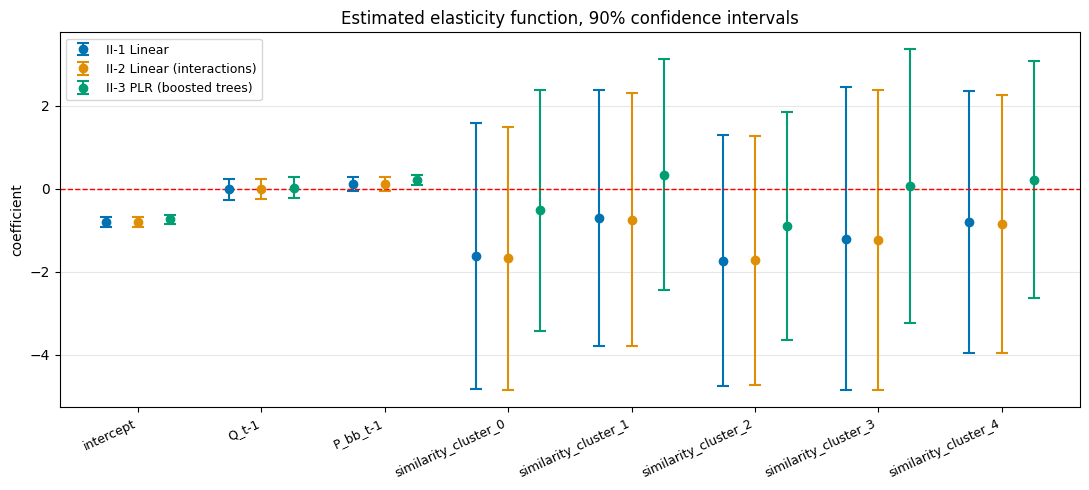

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
width = 0.26
x = np.arange(len(BASIS_COLS))

for i, (name, res) in enumerate(models.items()):
    ci = res.conf_int(alpha=1 - CONFIDENCE)
    coef = res.params.reindex(BASIS_COLS)
    lo, hi = ci[0].reindex(BASIS_COLS), ci[1].reindex(BASIS_COLS)
    ax.errorbar(x + (i - 1) * width, coef, yerr=[coef - lo, hi - coef],
                fmt="o", ms=6, capsize=4, capthick=1.5, lw=1.5,
                color=palette[i], ecolor=palette[i], label=name)

ax.axhline(0, color="red", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(BASIS_COLS, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("coefficient")
ax.set_title(f"Estimated elasticity function, {CONFIDENCE:.0%} confidence intervals")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The intercepts are close to the average effect from Lab 4: $-0.803$ and $-0.804$ in the linear models and $-0.742$ in Model II-3. The coefficient on lagged quantity is close to zero and insignificant in all three models. The coefficient on lagged price is positive: about $0.10$ and insignificant in the linear models, and $0.203$ with $t = 2.69$ in Model II-3. Products that were more expensive in the previous period thus react less strongly to price changes. None of the similarity coefficients is individually significant, and their confidence intervals are wide.

## Joint Significance of the Effect Modifiers

The individual coefficients on the similarities are imprecise because a product's five cosine similarities are nearly collinear: they measure closeness to five centroids on a sphere, so four of them almost determine the fifth. A joint test is therefore the appropriate way to ask whether product characteristics matter at all. Because of this near-collinearity, and following the paper, the test uses $k-1$ degrees of freedom for $k$ tested coefficients.

In [10]:
def chi2_test(res, idx):
    """Wald test that the selected coefficients are jointly zero."""
    coef = res.params.iloc[idx].to_numpy()
    cov = res.cov_params().to_numpy()[np.ix_(idx, idx)]
    stat = coef @ np.linalg.solve(cov, coef)
    return 1 - chi2.cdf(stat, len(idx) - 1)


joint = pd.DataFrame({
    "All modifiers": {n: chi2_test(r, MOD_IDX) for n, r in models.items()},
    "Similarities only": {n: chi2_test(r, SIM_IDX) for n, r in models.items()},
})
print(f"chi-squared p-values (sample size: {len(data):,})")
joint.round(4)

chi-squared p-values (sample size: 10,010)


,All modifiers,Similarities only
II-1 Linear,0.1160,0.1432
II-2 Linear (interactions),0.1279,0.1693
II-3 PLR (boosted trees),0.0023,0.0440


For Model II-3, the joint test rejects at the 5% level, both for all seven modifiers ($p = 0.002$) and for the similarities alone ($p = 0.044$). For the two linear models, the $p$-values lie between 0.12 and 0.17, so we cannot reject the hypothesis of no heterogeneity at conventional levels.

## Group Average Effects

As a coarser analysis, we assign each observation to the cluster to which it is most similar and estimate one average effect per group (GATE).

cluster             
similarity_cluster_1    2454
similarity_cluster_4    2223
similarity_cluster_2    2035
similarity_cluster_3    1908
similarity_cluster_0    1390


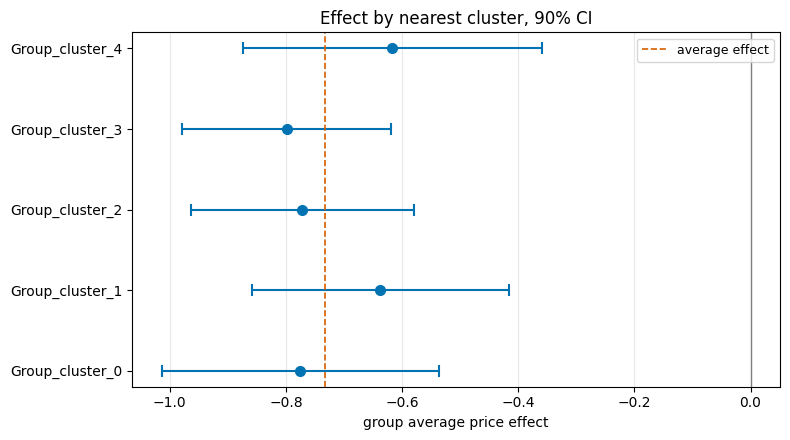

,5.0 %,effect,95.0 %
Group_similarity_cluster_0,-1.014,-0.775,-0.536
Group_similarity_cluster_1,-0.859,-0.637,-0.416
Group_similarity_cluster_2,-0.964,-0.772,-0.580
Group_similarity_cluster_3,-0.979,-0.799,-0.619
Group_similarity_cluster_4,-0.874,-0.617,-0.360


In [11]:
groups = pd.DataFrame(data[sim_cols].idxmax(axis=1), columns=["cluster"])
print(groups.value_counts().to_string())

gate = plr.gate(groups)
gate_summary = gate.confint(level=CONFIDENCE)

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(gate_summary))
coef = gate_summary.iloc[:, 1]
ax.errorbar(coef, y,
            xerr=[coef - gate_summary.iloc[:, 0], gate_summary.iloc[:, 2] - coef],
            fmt="o", ms=7, capsize=4, capthick=1.5, lw=1.5, color=palette[0])
ax.axvline(plr.coef[0], color=palette[3], ls="--", lw=1.2, label="average effect")
ax.axvline(0, color="gray", lw=1)
ax.set_yticks(y)
ax.set_yticklabels([s.replace("similarity_", "") for s in gate_summary.index])
ax.set_xlabel("group average price effect")
ax.set_title(f"Effect by nearest cluster, {CONFIDENCE:.0%} CI")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

gate_summary.round(3)

The groups contain between 1,390 and 2,454 observations. All five group effects are clearly negative, ranging from $-0.799$ for cluster 3 to $-0.617$ for cluster 4, and their 90% confidence intervals overlap. At this sample size, the grouping by nearest cluster therefore reveals no clear differences between the groups.

## Sorted Effects

Next, we predict $\hat\alpha(x)$ for every observation, sort the predictions in ascending order and plot them. The spread of the resulting curve summarizes the heterogeneity.

We show two confidence bands. The pointwise band covers the elasticity at a given percentile. The uniform band, obtained by a multiplier bootstrap of the maximal $t$-statistic, covers the whole curve simultaneously. It is the relevant band when we want to claim that products at the lower end of the curve are more price-sensitive than those at the upper end.

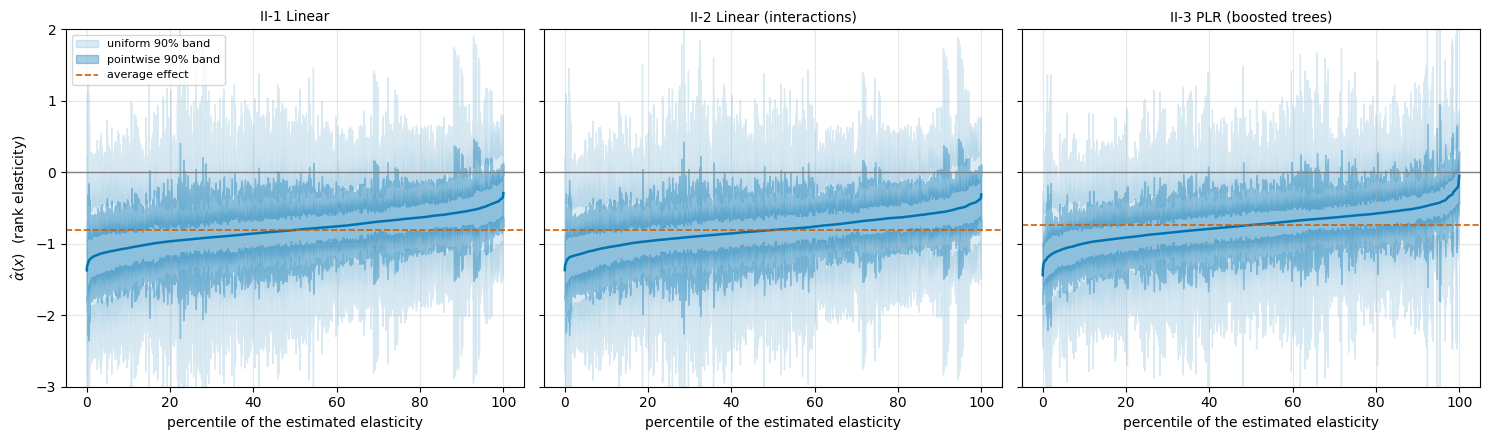

In [19]:
def effect_ci(res, basis, idx, level=CONFIDENCE, joint=False,
              n_boot=1000, seed=SEED):
    """Pointwise or uniform confidence band for basis @ coefficients."""
    b = basis.iloc[:, idx].to_numpy()
    coef = res.params.iloc[idx].to_numpy()
    cov = res.cov_params().to_numpy()[np.ix_(idx, idx)]

    effect = b @ coef
    se = np.sqrt(np.einsum("ij,jk,ik->i", b, cov, b))

    if joint:
        rng = np.random.default_rng(seed)
        root = np.real(sqrtm(cov))
        draws = (b @ root @ rng.normal(size=(len(idx), n_boot))).T / se
        crit = np.quantile(np.max(np.abs(draws), axis=0), level)
    else:
        crit = norm.ppf(0.5 + level / 2)

    return pd.DataFrame({"lower": effect - crit * se, "effect": effect,
                         "upper": effect + crit * se})


ALL_IDX = list(range(len(BASIS_COLS)))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (name, res) in zip(axes, models.items()):
    point = effect_ci(res, basis, ALL_IDX, joint=False)
    unif = effect_ci(res, basis, ALL_IDX, joint=True)
    order = np.argsort(point["effect"].values)
    pct = np.linspace(0, 100, len(order))

    ax.fill_between(pct, unif["lower"].values[order], unif["upper"].values[order],
                    color=palette[0], alpha=0.15, label="uniform 90% band")
    ax.fill_between(pct, point["lower"].values[order], point["upper"].values[order],
                    color=palette[0], alpha=0.35, label="pointwise 90% band")
    ax.plot(pct, point["effect"].values[order], color=palette[0], lw=1.8)
    ax.axhline(res.params["intercept"], color=palette[3], ls="--", lw=1.2,
               label="average effect")
    ax.axhline(0, color="gray", lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(-3, 2)
    ax.set_xlabel("percentile of the estimated elasticity")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("$\\hat{\\alpha}(x)$  (rank elasticity)")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
sorted_effects = effect_ci(models["II-3 PLR (boosted trees)"], basis, ALL_IDX)
rank = sorted_effects["effect"]

print("Estimated rank elasticity across products (Model II-3)")
print(rank.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_string())
print(f"\nimplied demand elasticity, 5th to 95th percentile: "
      f"{RANK_TO_DEMAND * rank.quantile(0.05):.2f} to "
      f"{RANK_TO_DEMAND * rank.quantile(0.95):.2f}")

Estimated rank elasticity across products (Model II-3)
count    10010.000
mean        -0.742
std          0.198
min         -1.439
5%          -1.072
25%         -0.878
50%         -0.737
75%         -0.604
95%         -0.430
max         -0.051

implied demand elasticity, 5th to 95th percentile: -2.14 to -0.86


For Model II-3, the estimated rank elasticities range from $-1.44$ to $-0.05$, with a mean of $-0.742$ and a standard deviation of 0.198. Between the 5th and the 95th percentile, they range from $-1.07$ to $-0.43$, which corresponds to demand elasticities between about $-2.1$ and $-0.9$. The pointwise bands exclude zero for most of the curve, but the uniform bands are wide and include zero almost everywhere. At this sample size, we therefore cannot claim with confidence that particular products are more elastic than others.

## Sources of Heterogeneity

The estimated elasticity is a function of seven variables. By regressing $\hat\alpha(x)$ on each block of variables in turn, we can see how the variation divides between what a product is and how popular and expensive it currently is.

In [14]:
alpha_hat = sorted_effects["effect"].values
blocks = {"256 embeddings": emb_cols,
          "5 similarities": sim_cols,
          "lagged Q, P": lag_controls}

share = {name: sm.OLS(alpha_hat, sm.add_constant(data[cols])).fit().rsquared
         for name, cols in blocks.items()}
print("share of Var(alpha-hat) explained")
for name, r2 in share.items():
    print(f"  {name:18s} {r2:6.1%}")

share of Var(alpha-hat) explained
  256 embeddings      69.4%
  5 similarities      42.5%
  lagged Q, P         12.0%


## Discussion

The five similarities alone explain 42.5% of the variance of $\hat\alpha(x)$, and the lagged price and quantity explain 12.0%. The 256 embeddings explain 69.4%. Since the similarities are linear functions of the embeddings, the embeddings explain at least as much as the similarities; the additional share reflects their correlation with the lagged state. Most of the estimated heterogeneity is thus associated with what a product is rather than with its current popularity or price.

**Price sensitivity varies across products.** Between the 5th and the 95th percentile, the estimated rank elasticities range from $-1.07$ to $-0.43$, that is, from about $-2.1$ to $-0.9$ in terms of demand. In the paper's full sample, the range is considerably wider, from about $-2.0$ to $+0.4$ in rank terms, or from $-4.0$ to $+0.8$ in demand terms, around an average near $-1.5$. Pricing every product based on the average elasticity would misprice products at both ends of the distribution.

**The effects of the individual modifiers differ from the paper.** In the paper's full sample, lagged quantity is the strongest modifier, with a coefficient of $-0.325$ and $t = -3.5$: products that already sell well lose proportionally more when their price rises. Here, its coefficient is close to zero in all three models. Lagged price, which has an insignificant negative coefficient in the paper, has a positive and significant coefficient in Model II-3. The coefficients on the lagged state are the ones that a smaller sample affects most, so these differences should not be overinterpreted.

**Product characteristics matter jointly, but the evidence is weaker than in the paper.** The individual similarity coefficients are imprecise because of their near-collinearity. The joint $\chi^2$ test rejects the hypothesis of no heterogeneity for Model II-3 at the 5% level, but not for the linear Models II-1 and II-2.

### The Two Roles of an Embedding

Taken together, Labs 3, 4 and 5 illustrate the paper's central claim.

| | Confounder? | Effect modifier? |
|---|---|---|
| **Evidence** | Lab 3: the embeddings barely predict $\Delta P$ | Lab 5: the joint $\chi^2$ test rejects for Model II-3, and $\hat\alpha(x)$ ranges from $-1.07$ to $-0.43$ (5th to 95th percentile) |
| **Consequence** | Lab 4: adding them hardly changes the linear estimates of $\delta$ | Lab 5: they indicate which products are more price-sensitive |

The embeddings are weak confounders but relevant effect modifiers. A model with homogeneous effects therefore recovers a reasonable average effect but is unreliable for any particular product. The value of representing products with AI methods lies less in a better estimate of the average effect than in identifying the products that the average does not describe well.

**Note:** Heterogeneity is what suffers most from the small sample. We estimate seven modifier coefficients from 10,010 observations, compared with 38,041 in the paper, so the individual similarity coefficients are imprecise and the uniform band includes zero for almost the whole curve. The joint $\chi^2$ test and the spread of $\hat\alpha(x)$ are more informative than individual $t$-statistics. Adding image part-files and raising `N_PRODUCTS` in Labs 1 and 2 sharpens the picture. The numbers also depend on the embeddings from Lab 2 and change slightly when Lab 2 is re-run.